<table style="width:100%">
  <tr>
    <td valign="top"><img src="../data/img/FER_logo_2.png" width=300 height=80 align="left"></td>
    <td valign="top"><img src="../data/img/LARES_2_transparent.png" width=250 height=80 align="right"></td>
  </tr>
 </table>

# Exploratory data analysis (EDA) and data processing

We use the Ames Housing dataset throughout the day.


## Part 0 - Setup

Run this cell first, in every notebook. It fetches the course repository into
the Colab session and moves into the `notebooks/` folder, so that the
`../data/...` paths work.

It is safe to run more than once, and safe after a restart.

Note: outside Colab the cell does nothing except report the working directory.
Start Jupyter from inside `notebooks/` and the paths work the same way.

If it prints `data ok: True`, you are set.

In [ ]:
# --- SETUP: run this first ---  [lares-setup-v1]
# works in Colab and locally; safe to run more than once
import os, sys, subprocess
REPO = "ai_bootcamp_foundations"
if "google.colab" in sys.modules:
    if not os.path.isdir(f"/content/{REPO}"):
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/hrvojenovak/{REPO}.git"],
                       cwd="/content", check=True)
    os.chdir(f"/content/{REPO}/notebooks")
print("cwd:", os.getcwd(), "| data ok:", os.path.isdir("../data"))

## Import libraries
Import all the necessary Python libraries.
Set some general options for plotting, suppress warnings etc.

In [1]:
import numpy as np, pandas as pd
from scipy.stats import norm

In [2]:
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt
tex_fonts = {
    "font.family": "serif",
    # Use 26pt font in plots
    "axes.labelsize": 20,
    "font.size": 20,
    "figure.titlesize": 20,
    # Make the legend/label fonts a little smaller
    "legend.title_fontsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
}

plt.rcParams.update(tex_fonts)

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Ames Housing dataset

Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, our **goal is to predict the final price of each home**.

The Ames Housing dataset was compiled by Dean De Cock for use in data science education. It's an incredible alternative for data scientists looking for a modernized and expanded version of the often cited Boston Housing dataset. The dataset, along many exemplary notebooks can be found on [Kaggle](https://www.kaggle.com/c/house-prices-advanced-regression-techniques). Keep in mind, the Kaggle version of the dataset keeps 50% of house prices hidden for scoring purposes - full version of the dataset can be found [here](https://www.kaggle.com/datasets/prevek18/ames-housing-dataset).

![title](../data/img/house_prices.jpg)

## Load dataset

In [4]:
# load the stored dataset from the data/ folder and print out few of the first rows for easier visual checking.
df = pd.read_csv('../data/housing_prices/housing.csv',index_col='Id')
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# dataframe properties
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

## Part 1 - Check basic dataset properties
Check some basic properties of the dataset to get a better sense of the data we are dealing with such as:
- check the size of the dataset (rows - data recordings, columns - inputs/features)
- check what are the available inputs/features (column names)
- check the types of available inputs/features
- check some basic statistical properties of the data
- missing values

In [6]:
# dataset size (rows, columns)
print('Size of dataset', df.shape)

Size of dataset (1460, 80)


In [7]:
# dataset columns (possible features)
print(len(df.columns))
print(df.columns.values)

80
['MSSubClass' 'MSZoning' 'LotFrontage' 'LotArea' 'Street' 'Alley'
 'LotShape' 'LandContour' 'Utilities' 'LotConfig' 'LandSlope'
 'Neighborhood' 'Condition1' 'Condition2' 'BldgType' 'HouseStyle'
 'OverallQual' 'OverallCond' 'YearBuilt' 'YearRemodAdd' 'RoofStyle'
 'RoofMatl' 'Exterior1st' 'Exterior2nd' 'MasVnrType' 'MasVnrArea'
 'ExterQual' 'ExterCond' 'Foundation' 'BsmtQual' 'BsmtCond' 'BsmtExposure'
 'BsmtFinType1' 'BsmtFinSF1' 'BsmtFinType2' 'BsmtFinSF2' 'BsmtUnfSF'
 'TotalBsmtSF' 'Heating' 'HeatingQC' 'CentralAir' 'Electrical' '1stFlrSF'
 '2ndFlrSF' 'LowQualFinSF' 'GrLivArea' 'BsmtFullBath' 'BsmtHalfBath'
 'FullBath' 'HalfBath' 'BedroomAbvGr' 'KitchenAbvGr' 'KitchenQual'
 'TotRmsAbvGrd' 'Functional' 'Fireplaces' 'FireplaceQu' 'GarageType'
 'GarageYrBlt' 'GarageFinish' 'GarageCars' 'GarageArea' 'GarageQual'
 'GarageCond' 'PavedDrive' 'WoodDeckSF' 'OpenPorchSF' 'EnclosedPorch'
 '3SsnPorch' 'ScreenPorch' 'PoolArea' 'PoolQC' 'Fence' 'MiscFeature'
 'MiscVal' 'MoSold' 'YrSold' 'SaleType

In [8]:
# dataset column types
df.dtypes.value_counts()

object     43
int64      34
float64     3
Name: count, dtype: int64

In [9]:
# basic dataset statistics
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [10]:
# make it a little bit easier on the eyes :)
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


**Conclusions**:
- *lot of possible features (80), 37 numeric, 43 categorical: doesn't seem likely that we will use them all,*
- *different ranges within the feature set (e.g. LotArea [1300, 215245], OverallQual [1, 10]),*
- *missing values for some features.*

### Missing values
Check and handle (remove or fill - if possible) missing values of data.

In [11]:
# find the columns with the largest amounts of missing data
total = df.isnull().sum().sort_values(ascending = False)
percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
missing_data  = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageYrBlt,81,5.547945
GarageCond,81,5.547945
GarageType,81,5.547945


In [12]:
# remove all features with over 0.5% of missing data
df = df.drop((missing_data[missing_data['Percent'] > 0.5]).index, axis=1)
# remove the single data with missing 'Electrical' data
df = df.drop(df.loc[df['Electrical'].isnull()].index)
# check the new dataset size
print('Size of dataset', df.shape)

Size of dataset (1459, 62)


> ### Decide, do not just run the cell
>
> We just dropped **18 features** because more than 0.5% of their values were
> missing. That is a threshold somebody chose, not a law.
>
> - Would you have used a different threshold? What does 5% cost you compared
>   with 0.5%?
> - `LotFrontage` was missing 17.7% and is now gone. `GarageQual` was missing
>   5.5%. Would you have imputed either of them instead?
> - What is the argument for keeping a column that is 95% empty?
>
> Two sentences in the cell below. No code needed.

<!-- your answer here -->

**Answer:**


**Conclusions**:
- *large number of sparse (unusablle) features,*
- *removed 18 features and one row with missing Electrical.*

## Part 2 - Exploratory data analysis (EDA)
Take a closer look into the available dataset:
- analyze the variable we are trying to predict in more detail (basic statistics, distribution)
- correlations between variables
- outliers?
- closer look into the most likely features

### Sale Price variable

In [13]:
# basic statistics (again)
df['SalePrice'].describe()

count      1459.000000
mean     180930.394791
std       79468.964025
min       34900.000000
25%      129950.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

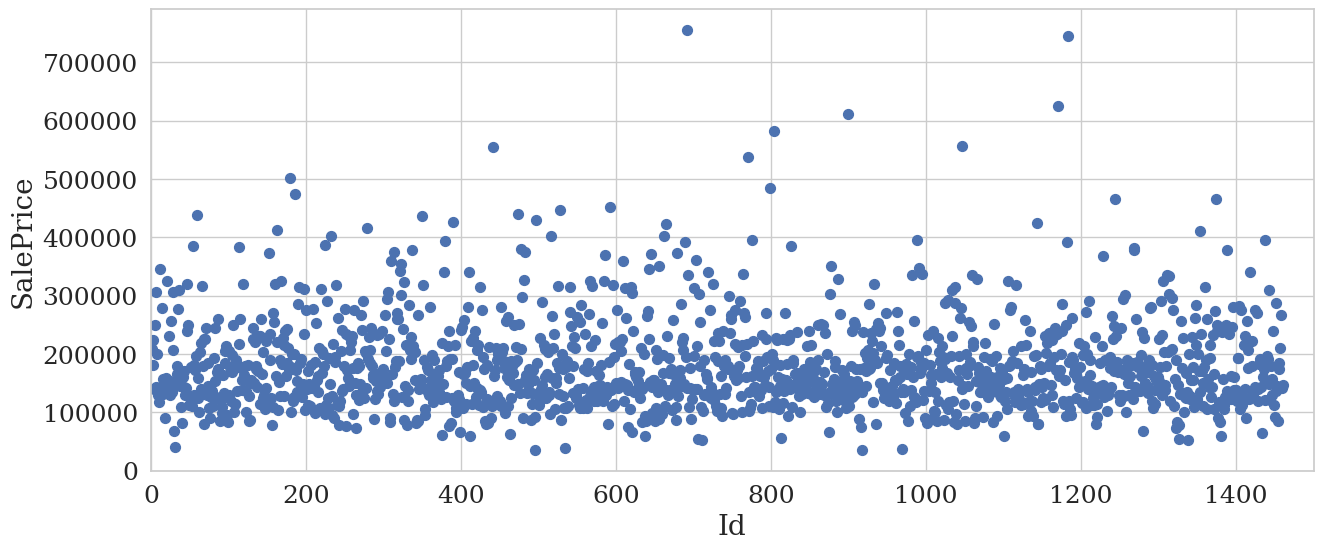

In [14]:
# scatter plot for all sales price data
plt.figure(figsize=(15,6))
plt.scatter(df.index,df['SalePrice'], s=50)
plt.xlim(0,1500)
plt.xlabel('Id')
plt.ylabel('SalePrice');

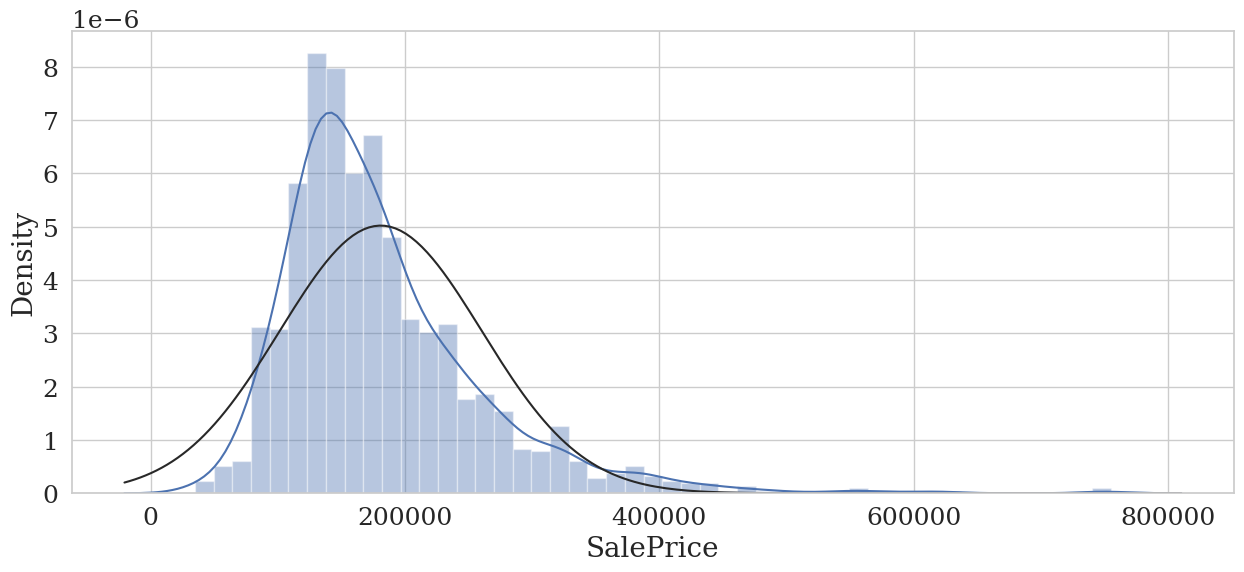

In [15]:
#histogram and normal probability plot
plt.figure(figsize=(15,6))
sns.histplot(df['SalePrice'], kde=True);

In [16]:
#skewness and kurtosis
print("Skewness: %f" % df['SalePrice'].skew()) 
print("Kurtosis: %f" % df['SalePrice'].kurt())

Skewness: 1.881943
Kurtosis: 6.529263


The histogram is an effective graphical technique for showing both the skewness and kurtosis of data set.

Skewness is a measure of symmetry, or more precisely, the lack of symmetry. The skewness for a normal distribution is zero, and any symmetric data should have a skewness near zero (negative - skewed left, positive - skewed right).

Kurtosis is a measure of whether the data are heavy-tailed or light-tailed relative to a normal distribution. The kurtosis for a standard normal distribution is three. Pandas uses Fisher’s definition of kurtosis (kurt-3).

**Conclusions**:
- *skewed distribution of the target variable*,
- *outliers present*,
- *some houses with very high prices.*

### Correlations
Correlation coefficients are used to measure how strong a relationship is between two variables. There are several types of correlation coefficient, but the most popular is Pearson’s.

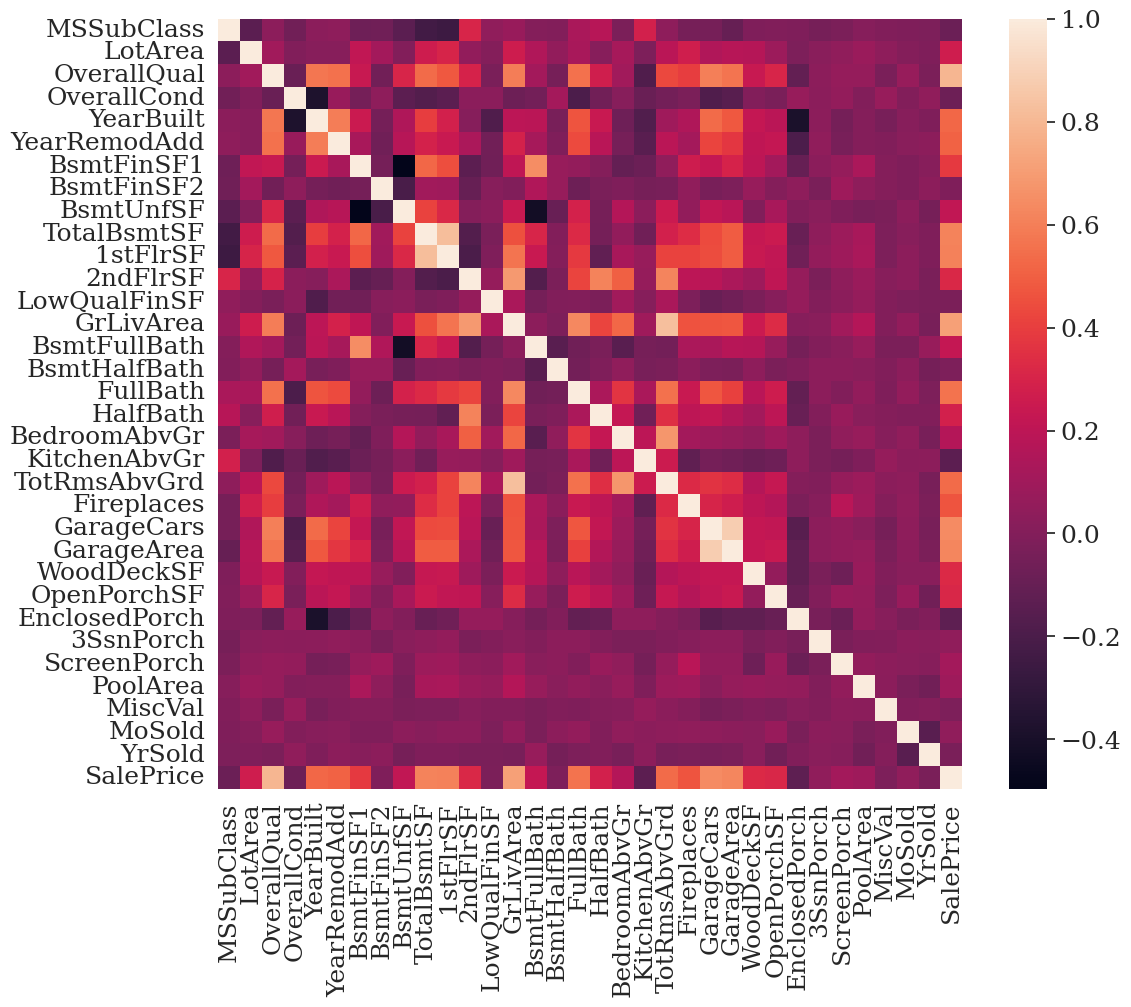

In [17]:
# calculate and plot all correlations...
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns);

In [18]:
# sort the correlations between features and Sale price
corr['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.791069
GrLivArea        0.708618
GarageCars       0.640473
GarageArea       0.623423
TotalBsmtSF      0.613905
1stFlrSF         0.605968
FullBath         0.560881
TotRmsAbvGrd     0.533779
YearBuilt        0.523273
YearRemodAdd     0.507430
Fireplaces       0.466968
BsmtFinSF1       0.386436
WoodDeckSF       0.324422
2ndFlrSF         0.319464
OpenPorchSF      0.315831
HalfBath         0.284400
LotArea          0.263837
BsmtFullBath     0.227082
BsmtUnfSF        0.214446
BedroomAbvGr     0.168235
ScreenPorch      0.111419
PoolArea         0.092397
MoSold           0.046380
3SsnPorch        0.044571
BsmtFinSF2      -0.011412
BsmtHalfBath    -0.016873
MiscVal         -0.021200
LowQualFinSF    -0.025620
YrSold          -0.028907
OverallCond     -0.077924
MSSubClass      -0.084230
EnclosedPorch   -0.128627
KitchenAbvGr    -0.135935
Name: SalePrice, dtype: float64

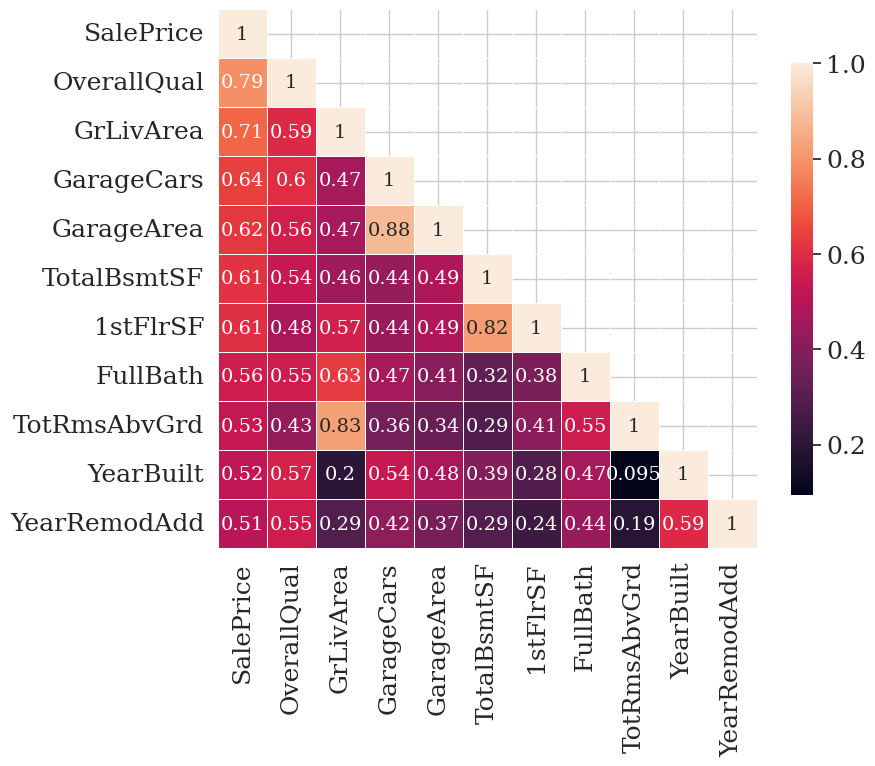

In [19]:
# plot correlations of the 10 most correlated features
relevant_inp = np.abs(corr['SalePrice']).sort_values(ascending=False).index[0:11]
relevant_corr = df[relevant_inp].corr(numeric_only=True)

# create a mask for the lower corr triangle only
mask = np.zeros_like(relevant_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# want diagonal elements as well
mask[np.diag_indices_from(mask)] = False

# plot the corr heatmap
plt.figure(figsize=(9,7))
sns.heatmap(relevant_corr, xticklabels=relevant_corr.columns, yticklabels=relevant_corr.columns,
        mask=mask, square=True, annot=True, linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"fontsize":14});

> ### Decide, do not just run the cell
>
> We ranked features by correlation with `SalePrice` and kept the top ten. It is
> a reasonable default and it has a blind spot.
>
> - `df.corr()` was called with `numeric_only=True`. This dataset has 43
>   **categorical** columns. Where are they in this ranking?
> - `GarageArea` and `GarageCars` correlate strongly with each other. Is
>   keeping both an advantage or a problem?
> - Suppose a column recorded the estate agent's own valuation. It would top
>   this ranking. Would you keep it?
>
> Hold on to the first question. This afternoon's exercise turns on it.

<!-- your answer here -->

**Answer:**


**Conclusions**:
- *a lot of uncorrelated variables that can be omitted,*
- *high correlation with the expected variables (common knowledge): overall house quality, living area, garage, bathroom, year built and remodelled...*
- *some variable highly correlate among themselves and perhaps can be merged or reduced (garage area and no. of garage cars).*

### Outliers
In statistics, an outlier is a data point that differs significantly from other observations.

In [20]:
# remember calculated correlations
relevant_inp[1:]

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
       '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')

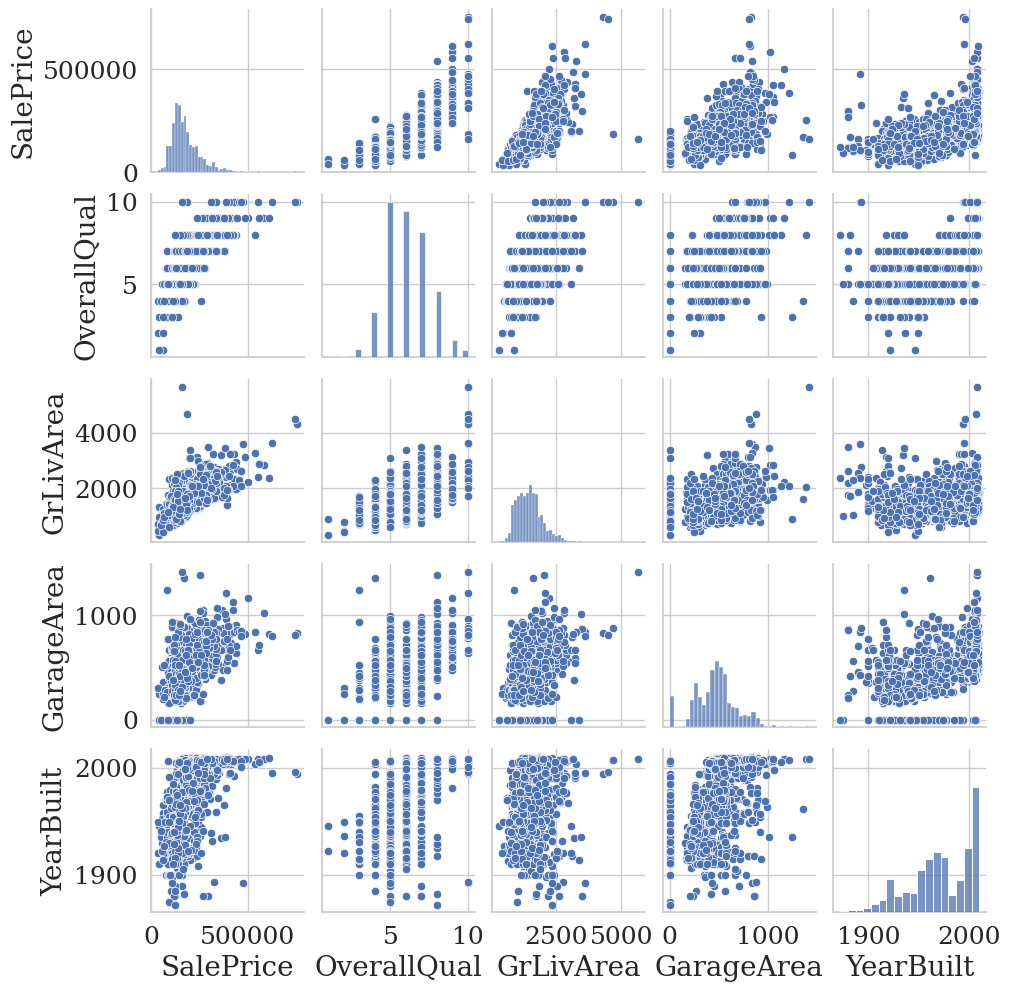

In [21]:
# plot pairwise relationships in a dataset
g = sns.pairplot(df[['SalePrice','OverallQual','GrLivArea','GarageArea','YearBuilt']])
g.fig.set_size_inches((10,10))

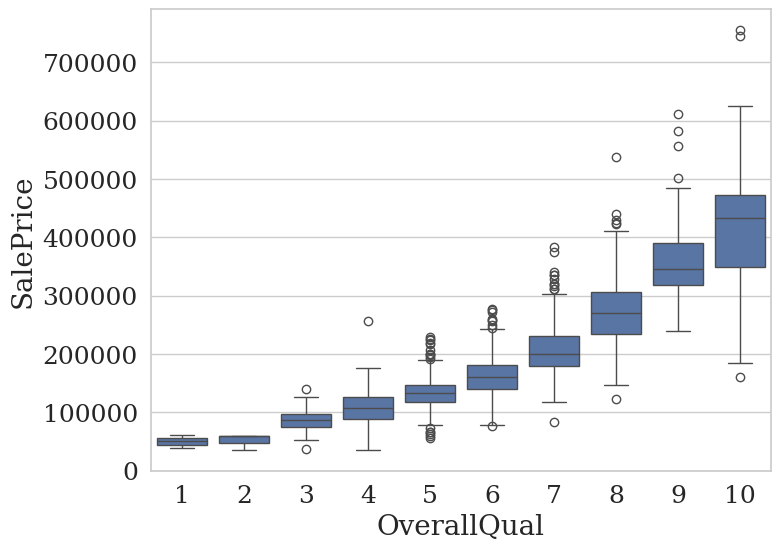

In [22]:
# plot box plots of sales prices with respect to the house overall quality ratings
plt.figure(figsize=(8,6))
g = sns.boxplot(x=df['OverallQual'],y=df['SalePrice'])

A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

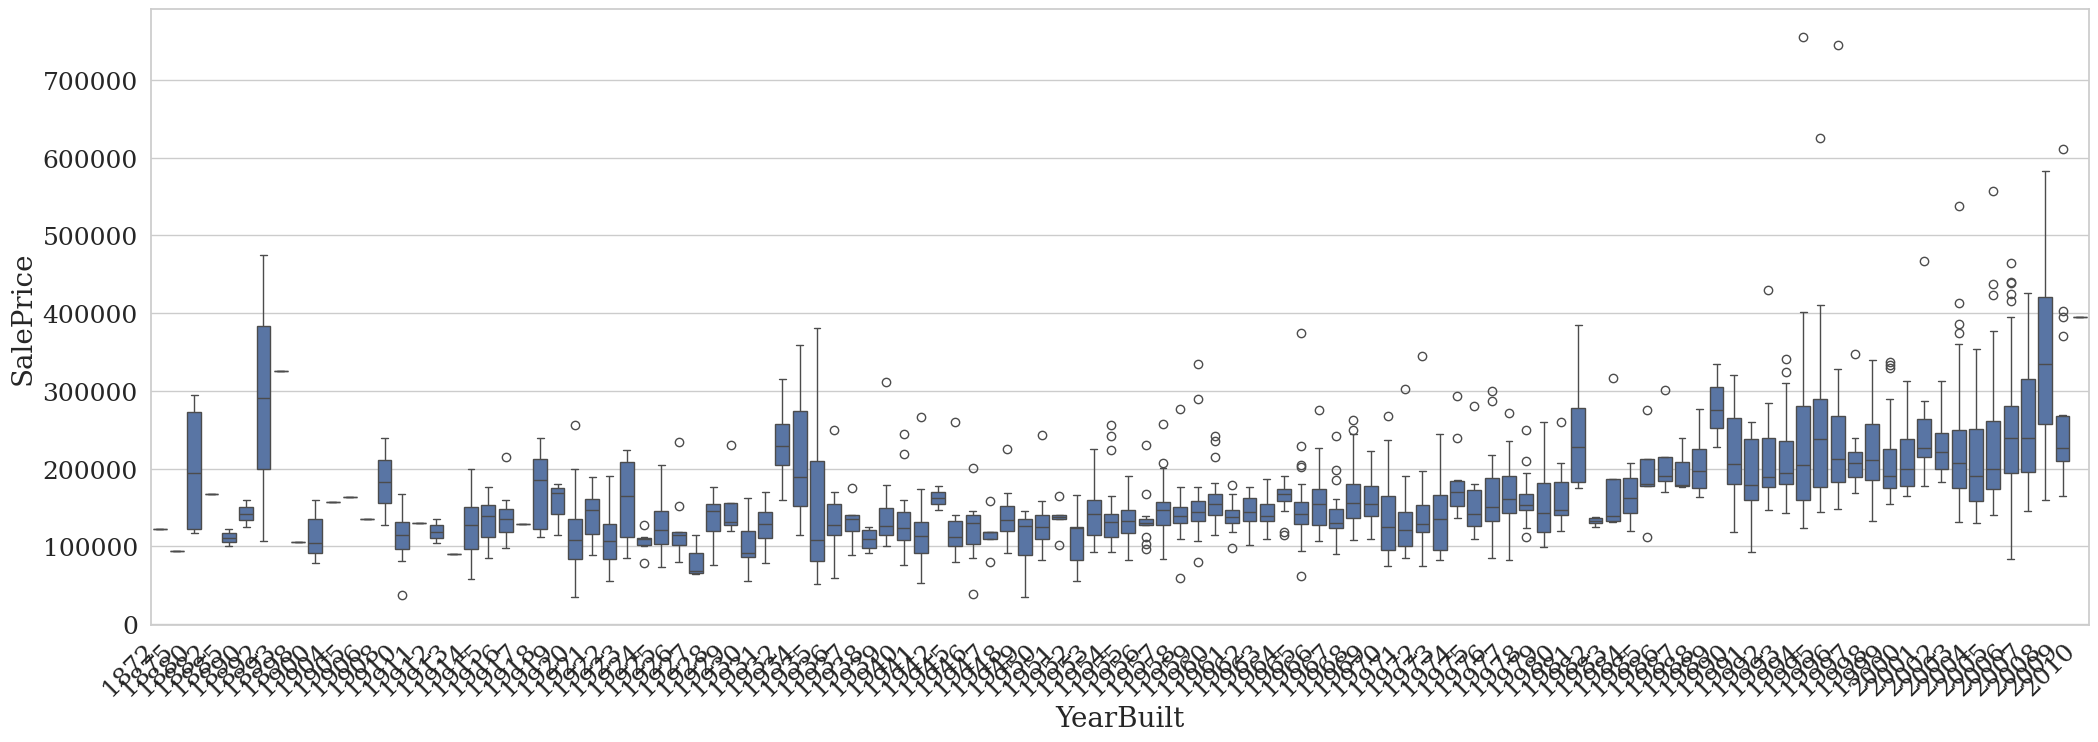

In [23]:
# box plots of sales prices with respect to house built year
plt.figure(figsize=(25,8))
g = sns.boxplot(x=df['YearBuilt'],y=df['SalePrice'], order=np.sort(df['YearBuilt'].unique()))
plt.xticks(rotation=45, ha='right');

**Conclusions**:
- *outliers present in most of the highly correlated features,*
- *since visual analysis shows good results, remove outliers manualy (e.g., two houses with almost largest living areas and bellow average prices),*
- *further investigate suspicious data and try to find out if there are some other reasons that are not shown in bivariate analysis (e.g., were the oldest houses with high prices been recently remodelled, or have large living areas, etc.).*

### Conclusions - overall:
- *lot of possible features (79), 36 numeric, 43 categorical: doesn't seem likely that will use them all,*
- *different ranges within the feature set (e.g. LotArea [1300, 215245], OverallQual [1, 10]),*
- *missing values for some features,*
- *large number of sparse (unusablle) features,*
- *removed 18 features and one row with missing Electrical,*
- *skewed distribution of the target variable*,
- *outliers present*,
- *some houses with very high prices,*
- *a lot of uncorrelated variables that can be omitted,*
- *high correlation with the expected variables (common knowledge): overall house quality, living area, garage, bathroom, year built and remodelled...*
- *some variable highly correlate among themselves and perhaps can be merged or reduced (garage area and no. of garage cars),*
- *outliers present in most of the highly correlated features,*
- *since visual analysis shows good results, remove outliers manualy (e.g., two houses with almost largest living areas and bellow average prices),*
- *further investigate suspicious data and try to find out if there are some other reasons that are not shown in bivariate analysis (e.g., were the oldest houses with high prices been recently remodelled, or have large living areas, etc.).*

## Part 3 - Process the training dataset
Once the available dataset is analysed with more detail, transform it into the appropriate form suitable for learning various models:
- categorical data encoding
- scaling/transforming
- splitting into train/val/test datasets

### Categorical data

In [24]:
# scikit-learn categorical variables encoders
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [25]:
# check if there are any categorical features in the most correlated ones
df[relevant_inp[1:]].head()

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd
Id,,,,,,,,,,
1,7,1710,2,548,856,856,2,8,2003,2003
2,6,1262,2,460,1262,1262,2,6,1976,1976
3,7,1786,2,608,920,920,2,6,2001,2002
4,7,1717,3,642,756,961,1,7,1915,1970
5,8,2198,3,836,1145,1145,2,9,2000,2000


In [26]:
# find other categorical features
categorical_var = df.select_dtypes(include='object')
categorical_var.columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [27]:
# let's see the 'Heating' categories
df['Heating'].unique()

array(['GasA', 'GasW', 'Grav', 'Wall', 'OthW', 'Floor'], dtype=object)

In [28]:
# let's see the 'MSZoning' categories
df['MSZoning'].unique()

array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object)

#### Label encoder

In [29]:
# use scikit-learn label encoder and create an instance for the 'Heating' categories
le = LabelEncoder()
aux = df['Heating']
aux = le.fit_transform(aux)
np.unique(aux)

array([0, 1, 2, 3, 4, 5])

In [30]:
# print the value-category map
le.classes_

array(['Floor', 'GasA', 'GasW', 'Grav', 'OthW', 'Wall'], dtype=object)

#### One-hot encoder

In [31]:
# use scikit-learn one-hot encoder and create an instance for both 'Heating' and 'MSZoning' categories
enc = OneHotEncoder(handle_unknown='ignore')
aux = df[['Heating','MSZoning']]
df_aux = enc.fit_transform(aux)
df_aux

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2918 stored elements and shape (1459, 11)>

### Dataset splitting
First we split the data into inputs (features) and outputs (targets).

Then we further split into the train-val-test parts of the dataset. The train-val-test split procedure is used to estimate the performance of machine learning algorithms when they are used to make predictions on data not used to train the model.

In [32]:
# split into intputs and outputs
# use only the 10 most correlated features (simplification for presentation purposes)
X = df[relevant_inp[1:]]
y = df[relevant_inp[0]]

In [33]:
# use scikit-learn dataset splitter
from sklearn.model_selection import train_test_split

# split the dataset into train - test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=1)

# separate dataset for validation?
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, shuffle=True, random_state=1) # 0.25 x 0.8 = 0.2

print('Train dataset size:', X_train.shape[0])
print('Validation dataset size:', X_val.shape[0])
print('Test dataset size:', X_test.shape[0])

Train dataset size: 875
Validation dataset size: 292
Test dataset size: 292


In [34]:
# keep only the original train-test split for future use
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=1)

print('Train dataset size:', X_train.shape[0])
print('Test dataset size:', X_test.shape[0])

Train dataset size: 1167
Test dataset size: 292


### Dataset scaling/transforming
Some machine learning algorithms are sensitive to feature scaling while others are virtually invariant to it. 

Machine learning algorithms like linear regression, logistic regression, neural network, etc. that use gradient descent as an optimization technique require data to be scaled. Distance algorithms like KNN, K-means, and SVM are most affected by the range of features. This is because behind the scenes they are using distances between data points to determine their similarity.

Distance algorithms like KNN, K-means, and SVM are most affected by the range of features. This is because behind the scenes they are using distances between data points to determine their similarity.

**NOTE:** we will proceed with the overall dataset (train and test parts together) only for presentation purposes. Additionally, we will not save the scaled versions of the data since the scaling is model dependent as said above.

In [35]:
# import scikit-learn scalers
from sklearn.preprocessing import MinMaxScaler, StandardScaler, QuantileTransformer, PowerTransformer

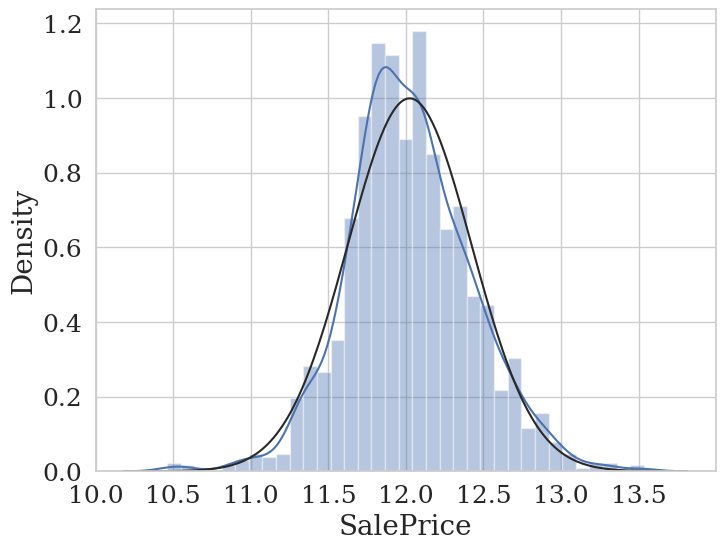

In [36]:
# log transformation
aux = np.log(df['SalePrice'])
plt.figure(figsize=(8,6))
sns.histplot(aux, kde=True);

The log transform fixes the skew almost completely (1.88 to 0.12). We are
**not** applying it to the saved target here: whether to model `SalePrice` or
`log(SalePrice)` is a modelling choice, and we make it on day 2.

Write the observation down now so it is not lost: *the target is right-skewed;
a log transform is available and worth testing.*

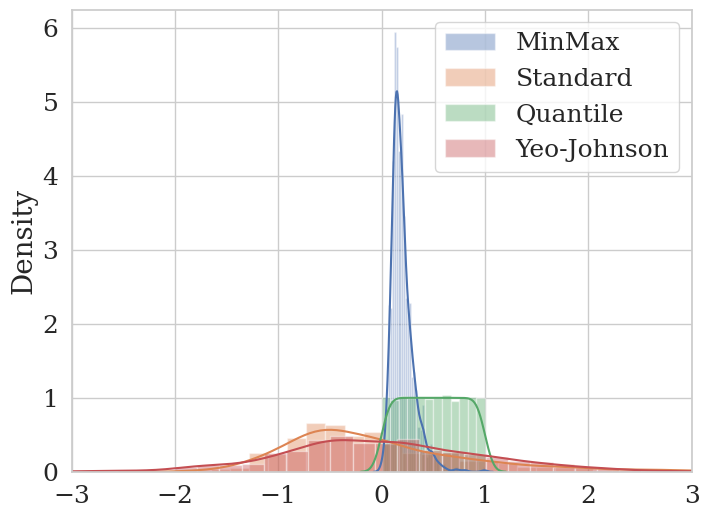

In [37]:
# scikit-learn scalers transformations and plotting
plt.figure(figsize=(8,6))
sns.histplot(MinMaxScaler().fit_transform(df['SalePrice'].values.reshape(-1, 1)),label='MinMax')
sns.histplot(StandardScaler().fit_transform(df['SalePrice'].values.reshape(-1, 1)),label='Standard')
sns.histplot(QuantileTransformer(output_distribution='uniform').fit_transform(df['SalePrice'].values.reshape(-1, 1)),label='Quantile')
sns.histplot(PowerTransformer(method='yeo-johnson').fit_transform(df['SalePrice'].values.reshape(-1, 1)),label='Yeo-Johnson')
plt.xlim([-3,3])
plt.legend();

In [38]:
# scale the inputs using the standard scaler
ss_inputs = StandardScaler()

X_train_scaled = ss_inputs.fit_transform(X_train)
X_test_scaled = ss_inputs.transform(X_test)
X_train_scaled

array([[-0.10106926, -0.26162924,  0.29285853, ..., -0.32541753,
         0.20605434, -0.36476242],
       [-0.82914229,  0.2309554 ,  0.29285853, ...,  0.2861159 ,
         0.17273965, -0.41358987],
       [-0.82914229, -0.54472386, -1.07420508, ..., -0.32541753,
        -0.4935541 ,  0.51413175],
       ...,
       [-0.10106926, -0.32013546, -2.4412687 , ...,  0.2861159 ,
        -1.92608565,  1.00240629],
       [-0.10106926, -1.01466092, -1.07420508, ..., -0.93695096,
        -0.02714847, -0.7065546 ],
       [-2.28528834, -1.19017959,  1.65992214, ..., -0.32541753,
        -1.22647722, -1.73193113]])

> ### Decide, do not just run the cell
>
> The scaler is fitted on the training set and only applied to the test set.
> One line, and it is the difference between an honest score and a useless one.
>
> - What exactly leaks if you call `fit_transform` on the whole dataset before
>   splitting? Name the quantity that carries the information.
> - Would that leak make your test score look better or worse than reality?
> - We are about to save these files to disk. Does anything scaled belong in
>   them, or only the raw split?
>
> Same again: two sentences, no code.

<!-- your answer here -->

**Answer:**


## Part 4 - Save the dataset

In [39]:
# save the training and test parts of the dataset for later usage
X_train.to_csv("../data/housing_prices/X_train.csv"); y_train.to_csv("../data/housing_prices/y_train.csv");
X_test.to_csv("../data/housing_prices/X_test.csv"); y_test.to_csv("../data/housing_prices/y_test.csv");

## Part 5 - Feature selection methods

Feature selection methods come in three families:
- *filter methods* - score each feature against the target, independently of any model,
- *wrapper methods* - train a model repeatedly and keep the features that help,
- *embedded methods* - selection comes for free from the model (Lasso, tree importances).

We run the filter methods below. Wrapper and embedded methods are in
`1x_Going_further_feature_selection`.

Note: we do not use the result - the ten features from the correlation ranking
stay. Feature selection is revisited on day 3, together with interpretability.


### Filter methods
Choose between the 10 most correlated features based on two different statistical test: Pearson correlation coefficient and mutual information measure.

In [40]:
# import scikit-learn feature selection functions
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
# filter based feature selection function
def feature_selection(function, name, X, y):
    selection = SelectKBest(score_func=function, k='all').fit(X, y)
    feature_scores = pd.DataFrame({'features': X.columns.values, 'scores': selection.scores_})
    print(feature_scores.sort_values(by=['scores'], ascending=False))
    feature_scores.plot(x='features', kind='bar', title=name, figsize=(8, 6))
    return feature_scores

       features       scores
0   OverallQual  1866.985819
1     GrLivArea  1178.313845
2    GarageCars   762.831172
4   TotalBsmtSF   696.951691
3    GarageArea   688.216312
5      1stFlrSF   662.207828
6      FullBath   551.499802
7  TotRmsAbvGrd   469.322300
8     YearBuilt   415.829118
9  YearRemodAdd   375.930058


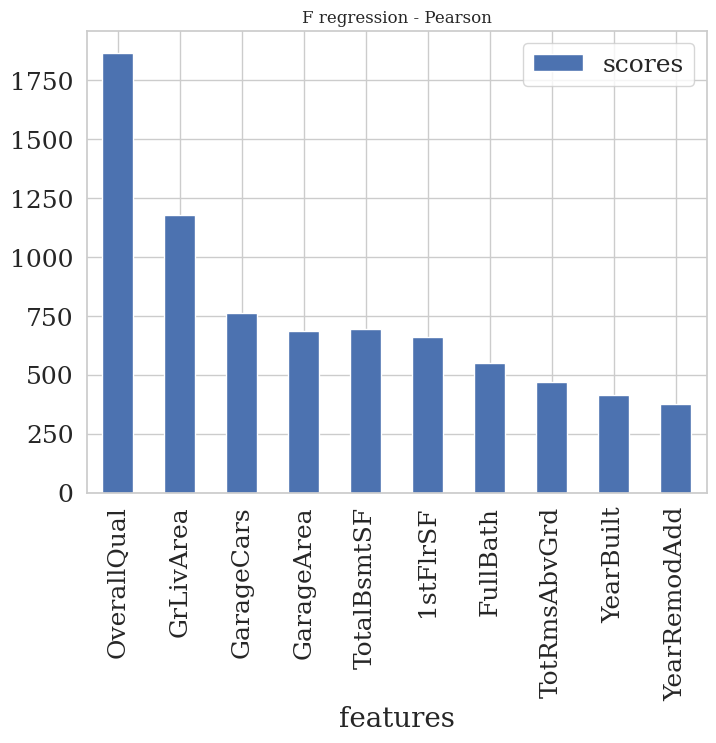

In [41]:
f_regression_scores = feature_selection(f_regression, 'F regression - Pearson', X_train, y_train)

       features    scores
0   OverallQual  0.565132
1     GrLivArea  0.466566
8     YearBuilt  0.366348
2    GarageCars  0.359860
3    GarageArea  0.353904
4   TotalBsmtSF  0.348589
5      1stFlrSF  0.317938
9  YearRemodAdd  0.264924
6      FullBath  0.258229
7  TotRmsAbvGrd  0.196992


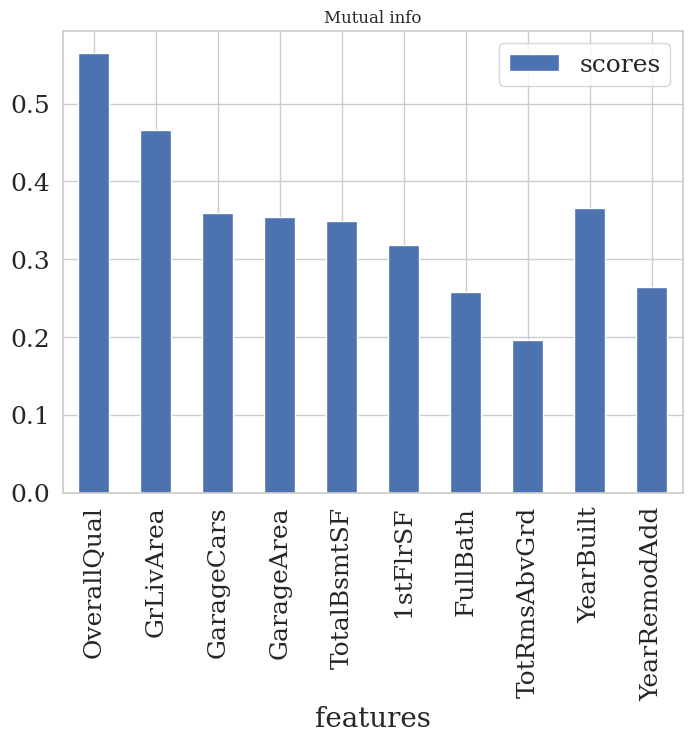

In [42]:
# apply feature selection based on Mutual information measure
mutual_info_scores = feature_selection(mutual_info_regression, 'Mutual info', X_train, y_train)

In [43]:
# compare obtained results
feature_scores = pd.DataFrame(index=relevant_inp[1:],columns=[['Pearson correlation', 'Mutual information']])
feature_scores['Pearson correlation'] = f_regression_scores.sort_values(by=['scores'], ascending=False).index
feature_scores['Mutual information'] = mutual_info_scores.sort_values(by=['scores'], ascending=False).index
feature_scores

,Pearson correlation,Mutual information
OverallQual,0,0
GrLivArea,1,1
GarageCars,2,8
GarageArea,4,2
TotalBsmtSF,3,3
1stFlrSF,5,4
FullBath,6,5
TotRmsAbvGrd,7,9
YearBuilt,8,6
YearRemodAdd,9,7


# The end :)



_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 1a_EDA_data_processing_  
_Instructors: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_  
_Intended user: XY_  
_Date: 1st January 1991_  

_References:_
- _Kaggle House Prices competition: https://www.kaggle.com/c/house-prices-advanced-regression-techniques_
- _Ames Housing Dataset (hosted on Kaggle): https://www.kaggle.com/datasets/prevek18/ames-housing-dataset_
- _FISHER, R.A. (1936), THE USE OF MULTIPLE MEASUREMENTS IN TAXONOMIC PROBLEMS. Annals of Eugenics, 7: 179-188. https://doi.org/10.1111/j.1469-1809.1936.tb02137.x_
- _Numerical Python - NumPy: https://numpy.org/_
- _Scientific Python - SciPy: https://scipy.org/_
- _Matplotlib: https://matplotlib.org/_
- _Scikit-learn Feature selection: https://scikit-learn.org/1.5/modules/feature_selection.html_
- _Scikit-learn Preprocessing data: https://scikit-learn.org/1.5/modules/preprocessing.html_
- _Scikit-learn Model selection and evaluation: https://scikit-learn.org/1.5/model_selection.html_

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_

